# Sentiment Analysis — Text Classification with RNN & LSTM
**Dataset:** IMDb Movie Reviews (Binary Sentiment)

This notebook covers the full pipeline:
1. Text Preprocessing, Tokenization & Padding
2. Model Building (Simple RNN, LSTM, LSTM + Word2Vec)
3. Training & Evaluation
4. Error Analysis
5. Real-Time Prediction GUI (Gradio)


## 0 — Install & Import Dependencies

In [77]:
import os, re, string, warnings
warnings.filterwarnings('ignore')

# Uninstall gensim first to ensure a clean install of the latest version
# This helps resolve potential caching issues with pip or conflicting installations
!pip uninstall gensim -y --quiet
!pip install gensim contractions==0.1.73 --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

# Define SEED for reproducibility
SEED = 42

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Setup complete ✓")

TensorFlow version: 2.20.0
NumPy version: 1.26.4
Setup complete ✓


### 1.1 Load the Dataset

In [22]:
import zipfile
import os

# Path to your zip file
zip_path = "/content/5. Movie Review Dataset-20260509T083916Z-3-001.zip"
extract_path = "/content/movie_dataset"

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Unzipped successfully")

# Check what was extracted
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print("📄", os.path.join(root, file))

✅ Unzipped successfully
📄 /content/movie_dataset/5. Movie Review Dataset/train_movie_review.csv
📄 /content/movie_dataset/5. Movie Review Dataset/val_movie_review.csv
📄 /content/movie_dataset/5. Movie Review Dataset/test_movie_review.csv
📄 /content/movie_dataset/5. Movie Review Dataset/5.Description Movie Review Dataset.txt


In [25]:
# Update BASE to point to the extracted folder containing the CSVs
# Assuming the zip file extracts to a folder named '5. Movie Review Dataset/'
BASE = '/content/movie_dataset/5. Movie Review Dataset/'

# Now try to load the dataframes again with the corrected path
train_df = pd.read_csv(BASE + 'train_movie_review.csv', index_col=0)
val_df   = pd.read_csv(BASE + 'val_movie_review.csv',   index_col=0)
test_df  = pd.read_csv(BASE + 'test_movie_review.csv',  index_col=0)

# Drop any unlabelled rows (NaN sentiment)
for df in [train_df, val_df, test_df]:
    df.dropna(subset=['sentiment'], inplace=True)

print(f'Train : {len(train_df):>6,} rows')
print(f'Val   : {len(val_df):>6,} rows')
print(f'Test  : {len(test_df):>6,} rows')
train_df.head(3)

Train : 35,000 rows
Val   :  5,000 rows
Test  : 10,000 rows


,review,sentiment
3774,"Having avoided seeing the movie in the cinema,...",0
48396,With this movie I was really hoping that the i...,0
1980,Raymond Burr stars as an attorney caught up in...,0


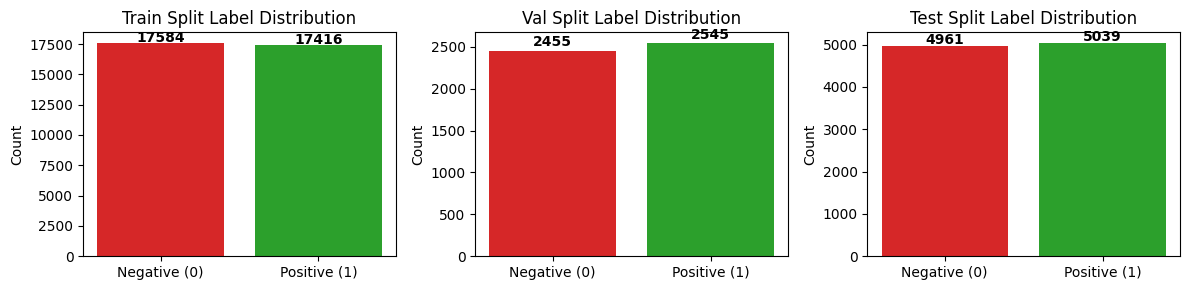

In [26]:
# Label distribution
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, (name, df) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    counts = df['sentiment'].value_counts()
    ax.bar(['Negative (0)', 'Positive (1)'], [counts.get(0,0), counts.get(1,0)],
           color=['#d62728', '#2ca02c'])
    ax.set_title(f'{name} Split Label Distribution')
    ax.set_ylabel('Count')
    for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
        ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2 Text Cleaning

In [27]:
lemmatizer  = WordNetLemmatizer()
STOP_WORDS  = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    """Full preprocessing pipeline for a single review string."""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove HTML tags (common in IMDb reviews)
    text = re.sub(r'<.*?>', ' ', text)
    # 3. Expand contractions  (don't → do not)
    text = contractions.fix(text)
    # 4. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # 5. Remove @mentions and #hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # 6. Remove numbers and special characters (keep letters & spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # 7. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # 8. Tokenise, remove stopwords, lemmatize
    tokens = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in STOP_WORDS and len(w) > 1
    ]
    return ' '.join(tokens)

# Apply to all splits
print('Cleaning text (this may take ~60 s on CPU)…')
for df in [train_df, val_df, test_df]:
    df['clean_review'] = df['review'].astype(str).apply(clean_text)

print('Done!\nSample original  :', train_df['review'].iloc[0][:120])
print('Sample cleaned   :', train_df['clean_review'].iloc[0][:120])

Cleaning text (this may take ~60 s on CPU)…
Done!
Sample original  : Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not exp
Sample cleaned   : avoided seeing movie cinema buying dvd wife xmas watch expect much usually mean get bargained mamma mia utter utter cr l


### 1.3 Visualise Cleaned Data

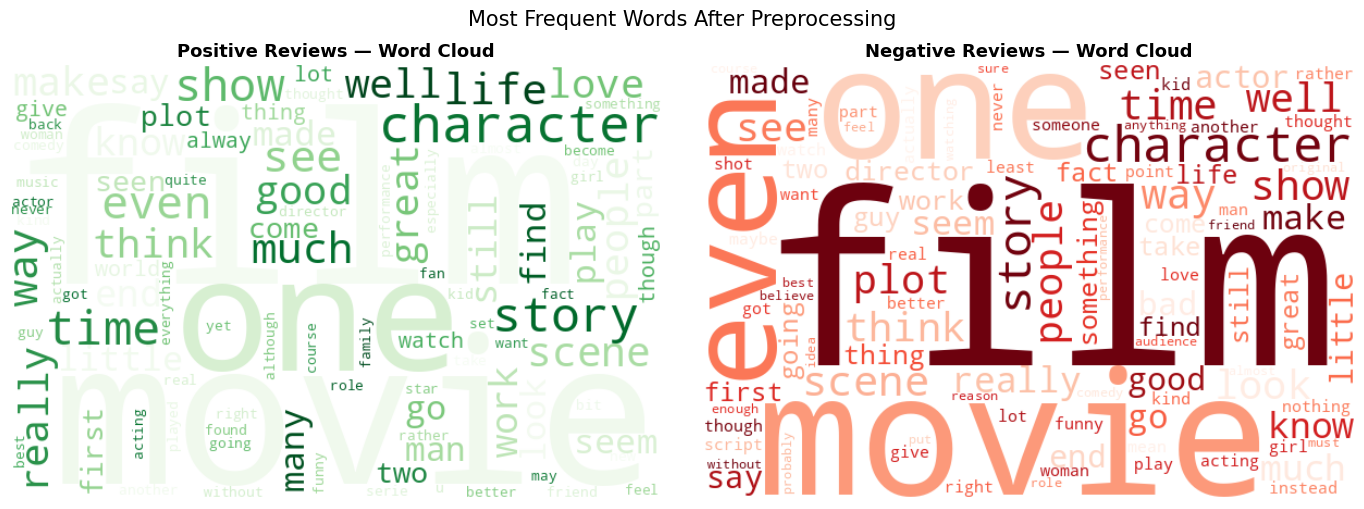

In [28]:
# ── Word Cloud ───────────────────────────────────────────────────────────────
pos_text = ' '.join(train_df[train_df['sentiment'] == 1]['clean_review'])
neg_text = ' '.join(train_df[train_df['sentiment'] == 0]['clean_review'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, text, title, cmap in [
    (axes[0], pos_text, 'Positive Reviews — Word Cloud', 'Greens'),
    (axes[1], neg_text, 'Negative Reviews — Word Cloud', 'Reds')
]:
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')
plt.suptitle('Most Frequent Words After Preprocessing', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('word_cloud.png', dpi=150, bbox_inches='tight')
plt.show()

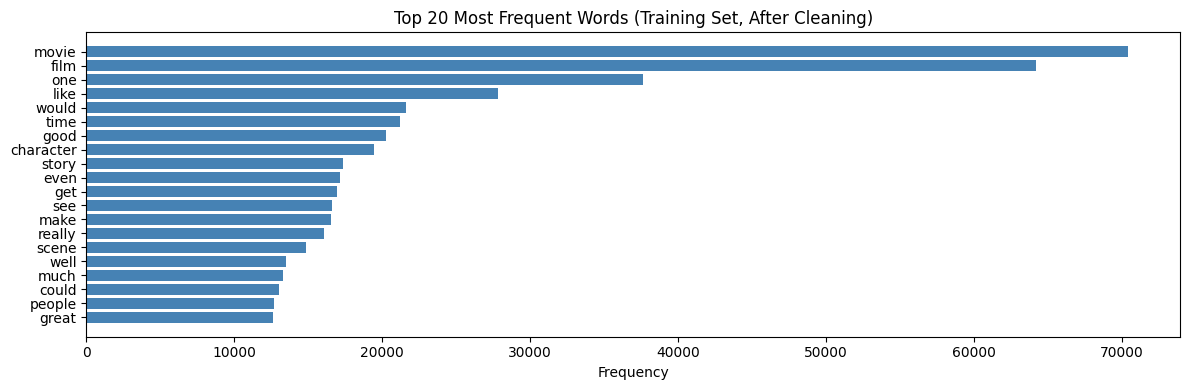

In [31]:
# ── Top-20 Most Frequent Words ────────────────────────────────────────────────
all_words = ' '.join(train_df['clean_review']).split()
freq = Counter(all_words).most_common(20)
words, counts = zip(*freq)

plt.figure(figsize=(12, 4))
bars = plt.barh(list(reversed(words)), list(reversed(counts)), color='steelblue')
plt.xlabel('Frequency')
plt.title('Top 20 Most Frequent Words (Training Set, After Cleaning)')
plt.tight_layout()
plt.savefig('top20_words.png', dpi=150, bbox_inches='tight')
plt.show()

count    35000.000000
mean       116.394857
std         87.848850
min          4.000000
25%         62.000000
50%         87.000000
75%        141.000000
max       1401.000000
Name: token_count, dtype: float64


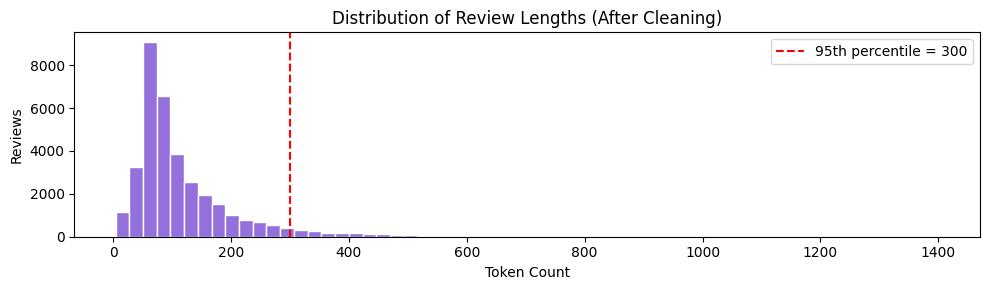

In [32]:
# ── Review length distribution (post-cleaning) ───────────────────────────────
train_df['token_count'] = train_df['clean_review'].apply(lambda x: len(x.split()))
print(train_df['token_count'].describe())

plt.figure(figsize=(10, 3))
plt.hist(train_df['token_count'], bins=60, color='mediumpurple', edgecolor='white')
p95 = int(np.percentile(train_df['token_count'], 95))
plt.axvline(p95, color='red', linestyle='--', label=f'95th percentile = {p95}')
plt.xlabel('Token Count'); plt.ylabel('Reviews')
plt.title('Distribution of Review Lengths (After Cleaning)')
plt.legend()
plt.tight_layout()
plt.savefig('length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.4 Tokenisation & Padding

In [37]:
# ── Hyper-parameters ─────────────────────────────────────────────────────────
VOCAB_SIZE   = 20_000          # top-k most frequent tokens
OOV_TOKEN    = '<OOV>'
MAX_LEN      = int(np.percentile(train_df['token_count'], 95))  # percentile-based
EMBED_DIM    = 64

print(f'MAX_LEN (95th percentile) = {MAX_LEN}')

# ── Tokenizer ────────────────────────────────────────────────────────────────
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train_df['clean_review'])   # fit on TRAIN only

def encode_and_pad(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train = encode_and_pad(train_df['clean_review'])
X_val   = encode_and_pad(val_df['clean_review'])
X_test  = encode_and_pad(test_df['clean_review'])

y_train = train_df['sentiment'].values
y_val   = val_df['sentiment'].values
y_test  = test_df['sentiment'].values

print(f'X_train shape : {X_train.shape}')
print(f'X_val   shape : {X_val.shape}')
print(f'X_test  shape : {X_test.shape}')

MAX_LEN (95th percentile) = 300
X_train shape : (35000, 300)
X_val   shape : (5000, 300)
X_test  shape : (10000, 300)


---
## Task 4.5.2 — Model Building

### Model 1 — Simple RNN with Trainable Embedding

In [40]:
def build_rnn_model(vocab_size, embed_dim, max_len):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len),
        SimpleRNN(64, return_sequences=False),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ], name='Model1_SimpleRNN')
    return model

model1 = build_rnn_model(VOCAB_SIZE, EMBED_DIM, MAX_LEN)
model1.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=1e-3),
    metrics=['accuracy']
)
model1.summary()

Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model 2 — LSTM with Trainable Embedding

In [41]:
def build_lstm_model(vocab_size, embed_dim, max_len):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ], name='Model2_LSTM')
    return model

model2 = build_lstm_model(VOCAB_SIZE, EMBED_DIM, MAX_LEN)
model2.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=1e-3),
    metrics=['accuracy']
)
model2.summary()

Model: "Model2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model 3 — LSTM with Pre-trained Word2Vec / GloVe Embeddings

In [52]:
# ── Step 1 : Download pre-trained GloVe embeddings via gensim ───────────────
# NOTE: Run the install block at the top if gensim is not available.
import gensim.downloader as api

print('Loading glove-wiki-gigaword-50 (~66 MB, may take a minute)…')
embedding_model = api.load('glove-wiki-gigaword-50')   # 50-dimensional GloVe
GLOVE_DIM = 50
print('GloVe loaded ✓')

Loading glove-wiki-gigaword-50 (~66 MB, may take a minute)…
[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe loaded ✓


In [53]:
# ── Step 2 : Build Embedding Matrix aligned to Keras tokenizer ───────────────
word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))

hits, misses = 0, 0
for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        hits += 1
    else:
        misses += 1

coverage = hits / (hits + misses) * 100
print(f'Vocabulary coverage : {hits} hits, {misses} misses  ({coverage:.1f}%)')

Vocabulary coverage : 19276 hits, 723 misses  (96.4%)


In [54]:
def build_lstm_glove_model(vocab_size, glove_dim, max_len, embedding_matrix):
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=glove_dim,
            input_length=max_len,
            weights=[embedding_matrix],
            trainable=False          # freeze pre-trained weights initially
        ),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ], name='Model3_LSTM_GloVe')
    return model

model3 = build_lstm_glove_model(VOCAB_SIZE, GLOVE_DIM, MAX_LEN, embedding_matrix)
model3.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=1e-3),
    metrics=['accuracy']
)
model3.summary()

Model: "Model3_LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

---
## Task 4.5.3 — Training & Evaluation

In [63]:
# ── Shared training settings ──────────────────────────────────────────────────
BATCH_SIZE = 128
MAX_EPOCHS = 20

def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True,
                      verbose=1),
        ModelCheckpoint(f'{name}_best.keras', save_best_only=True, verbose=0)
    ]

In [64]:
print('=' * 55)
print('Training Model 1 — Simple RNN')
print('=' * 55)
history1 = model1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('model1')
)

Training Model 1 — Simple RNN
Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 43s 156ms/step - accuracy: 0.5297 - loss: 0.6635 - val_accuracy: 0.4978 - val_loss: 0.7467
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 156ms/step - accuracy: 0.5260 - loss: 0.6697 - val_accuracy: 0.4952 - val_loss: 0.7315
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 155ms/step - accuracy: 0.5295 - loss: 0.6643 - val_accuracy: 0.4974 - val_loss: 0.7533
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 83s 158ms/step - accuracy: 0.5253 - loss: 0.6735 - val_accuracy: 0.4948 - val_loss: 0.7376
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 42s 154ms/step - accuracy: 0.5250 - loss: 0.6741 - val_accuracy: 0.4944 - val_loss: 0.7291
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 83s 159ms/step - accuracy: 0.5265 - loss: 0.6703 - val_accuracy: 0.4936 - val_loss: 0.7325
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 43s 158ms/step - accuracy: 0.5263 - loss: 0.6707 - val_accuracy: 0.4964 - val_loss: 0.7251
Epoch 8/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 83s 161ms/ste

In [59]:
print('=' * 55)
print('Training Model 2 — LSTM')
print('=' * 55)
history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('model2')
)

Training Model 2 — LSTM
Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 147s 519ms/step - accuracy: 0.5041 - loss: 0.6932 - val_accuracy: 0.4944 - val_loss: 0.6934
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 146s 532ms/step - accuracy: 0.5138 - loss: 0.6896 - val_accuracy: 0.4974 - val_loss: 0.6943
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 142s 519ms/step - accuracy: 0.5253 - loss: 0.6778 - val_accuracy: 0.5000 - val_loss: 0.6997
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 140s 511ms/step - accuracy: 0.5304 - loss: 0.6659 - val_accuracy: 0.4986 - val_loss: 0.7119
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


In [65]:
print('=' * 55)
print('Training Model 3 — LSTM + GloVe')
print('=' * 55)
history3 = model3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('model3')
)

Training Model 3 — LSTM + GloVe
Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 115s 421ms/step - accuracy: 0.5173 - loss: 0.6907 - val_accuracy: 0.4900 - val_loss: 0.6935
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 111s 404ms/step - accuracy: 0.5379 - loss: 0.6790 - val_accuracy: 0.4994 - val_loss: 0.6925
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 111s 407ms/step - accuracy: 0.5330 - loss: 0.6794 - val_accuracy: 0.5098 - val_loss: 0.6931
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 148s 427ms/step - accuracy: 0.5127 - loss: 0.6898 - val_accuracy: 0.5164 - val_loss: 0.6856
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 112s 408ms/step - accuracy: 0.5499 - loss: 0.6791 - val_accuracy: 0.5432 - val_loss: 0.6771
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 111s 407ms/step - accuracy: 0.5396 - loss: 0.6826 - val_accuracy: 0.5218 - val_loss: 0.6842
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 115s 417ms/step - accuracy: 0.6399 - loss: 0.6476 - val_accuracy: 0.6350 - val_loss: 0.6425
Epoch 8/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 144s

### Training / Validation Curves — Per Model

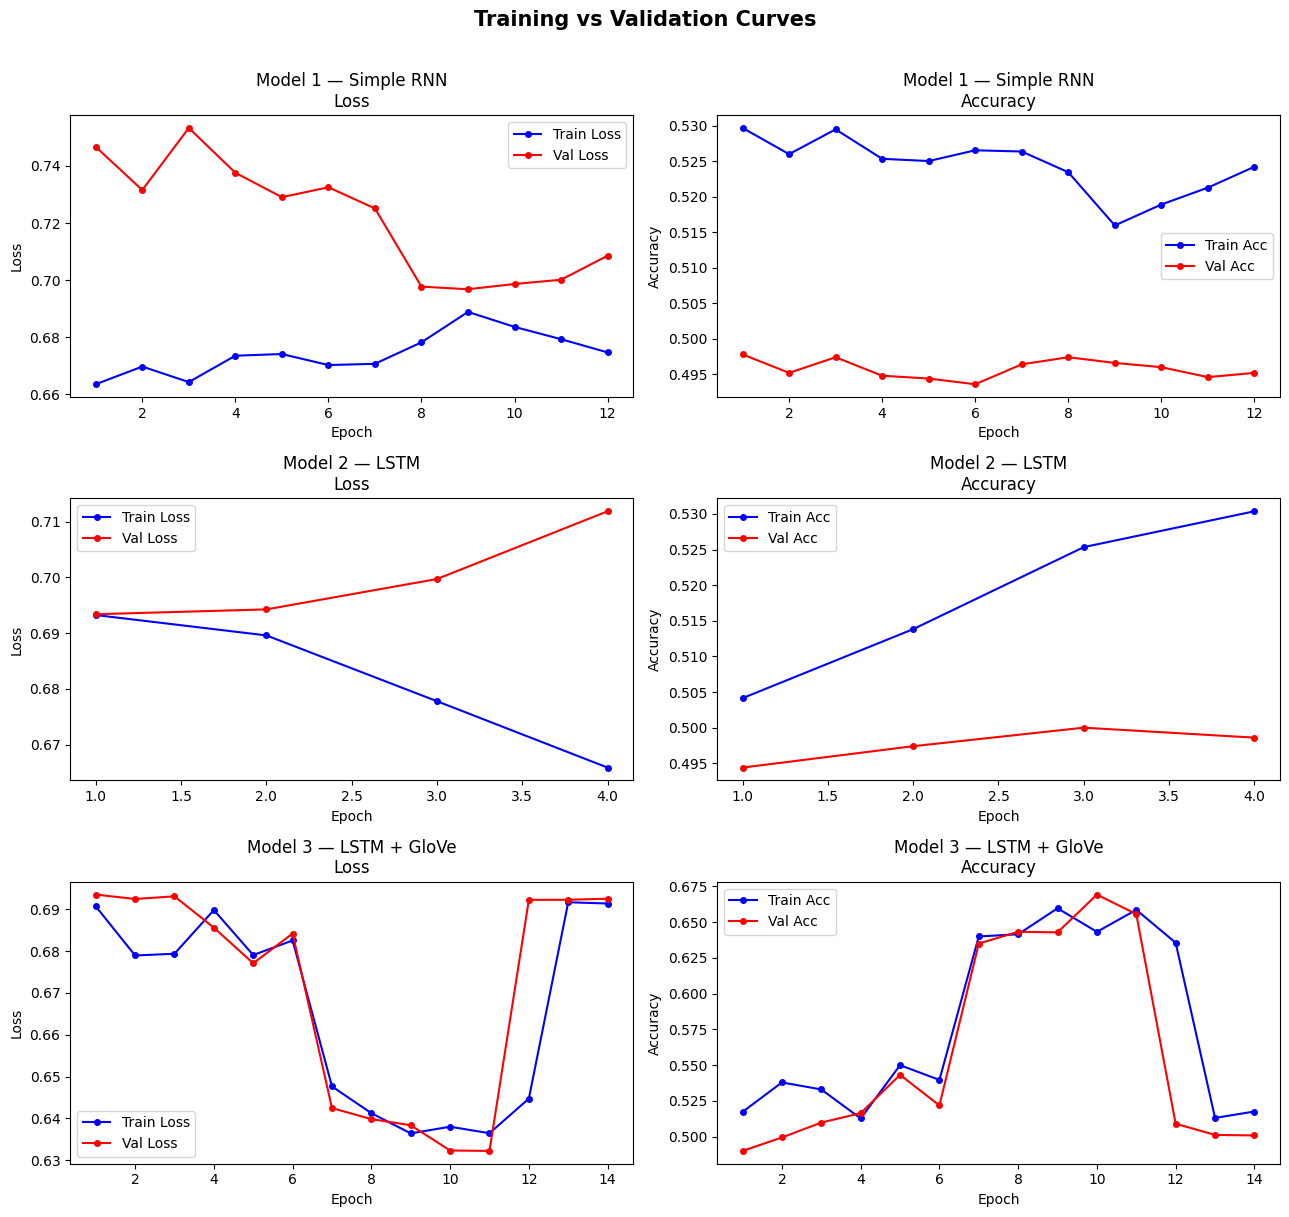

In [66]:
def plot_history(history, title, ax_loss, ax_acc):
    epochs = range(1, len(history.history['loss']) + 1)
    ax_loss.plot(epochs, history.history['loss'],     'b-o', ms=4, label='Train Loss')
    ax_loss.plot(epochs, history.history['val_loss'], 'r-o', ms=4, label='Val Loss')
    ax_loss.set_title(f'{title}\nLoss')
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
    ax_loss.legend()

    ax_acc.plot(epochs, history.history['accuracy'],     'b-o', ms=4, label='Train Acc')
    ax_acc.plot(epochs, history.history['val_accuracy'], 'r-o', ms=4, label='Val Acc')
    ax_acc.set_title(f'{title}\nAccuracy')
    ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()

fig, axes = plt.subplots(3, 2, figsize=(13, 12))
for i, (hist, name) in enumerate([
    (history1, 'Model 1 — Simple RNN'),
    (history2, 'Model 2 — LSTM'),
    (history3, 'Model 3 — LSTM + GloVe')
]):
    plot_history(hist, name, axes[i][0], axes[i][1])

plt.suptitle('Training vs Validation Curves', fontsize=15, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Compare All Three Models

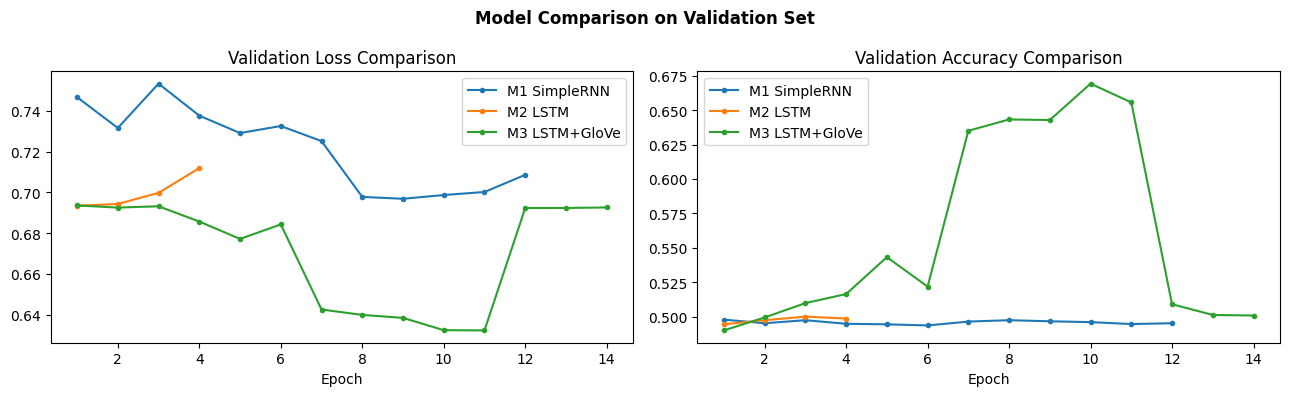

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels = ['M1 SimpleRNN', 'M2 LSTM', 'M3 LSTM+GloVe']

for hist, label, color in zip([history1, history2, history3], labels, colors):
    ep = range(1, len(hist.history['val_loss']) + 1)
    ax1.plot(ep, hist.history['val_loss'],     color=color, marker='o', ms=3, label=label)
    ax2.plot(ep, hist.history['val_accuracy'], color=color, marker='o', ms=3, label=label)

ax1.set_title('Validation Loss Comparison');     ax1.set_xlabel('Epoch'); ax1.legend()
ax2.set_title('Validation Accuracy Comparison'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.suptitle('Model Comparison on Validation Set', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Test-Set Evaluation

In [72]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate_model(model, X, y, name):
    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y, y_pred)
    cm = confusion_matrix(y, y_pred)
    report = classification_report(y, y_pred, target_names=['Negative','Positive'])

    print(f'\n{"─"*50}')
    print(f'  {name}')
    print(f'  Test Accuracy : {acc:.4f}')
    print(f'{"─"*50}')
    print(report)

    return y_pred, y_prob, cm

pred1, prob1, cm1 = evaluate_model(model1, X_test, y_test, 'Model 1 — Simple RNN')
pred2, prob2, cm2 = evaluate_model(model2, X_test, y_test, 'Model 2 — LSTM')
pred3, prob3, cm3 = evaluate_model(model3, X_test, y_test, 'Model 3 — LSTM + GloVe')


──────────────────────────────────────────────────
  Model 1 — Simple RNN
  Test Accuracy : 0.5017
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.50      0.97      0.66      4961
    Positive       0.58      0.04      0.08      5039

    accuracy                           0.50     10000
   macro avg       0.54      0.51      0.37     10000
weighted avg       0.54      0.50      0.37     10000


──────────────────────────────────────────────────
  Model 2 — LSTM
  Test Accuracy : 0.5005
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.50      0.95      0.65      4961
    Positive       0.54      0.06      0.11      5039

    accuracy                           0.50     10000
   macro avg       0.52      0.50      0.38     10000
weighted avg       0.52      0.50      0.38     10000


─────────────────────────────────────────────────

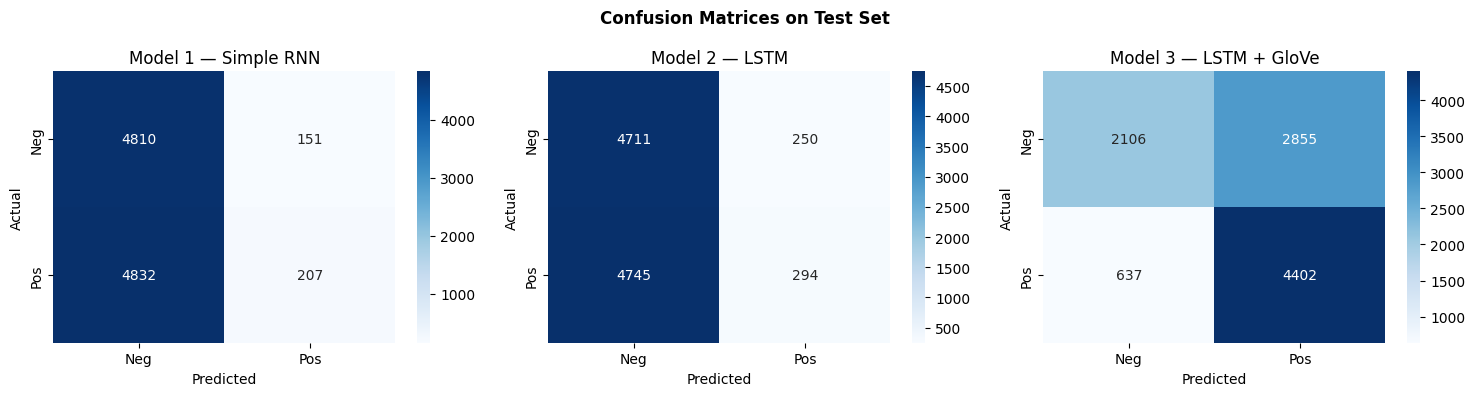

In [73]:
# ── Confusion Matrices ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, cm, title in zip(
    axes,
    [cm1, cm2, cm3],
    ['Model 1 — Simple RNN', 'Model 2 — LSTM', 'Model 3 — LSTM + GloVe']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices on Test Set', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

,Model,Test Accuracy
0,Simple RNN,0.5017
1,LSTM,0.5005
2,LSTM + GloVe,0.6508


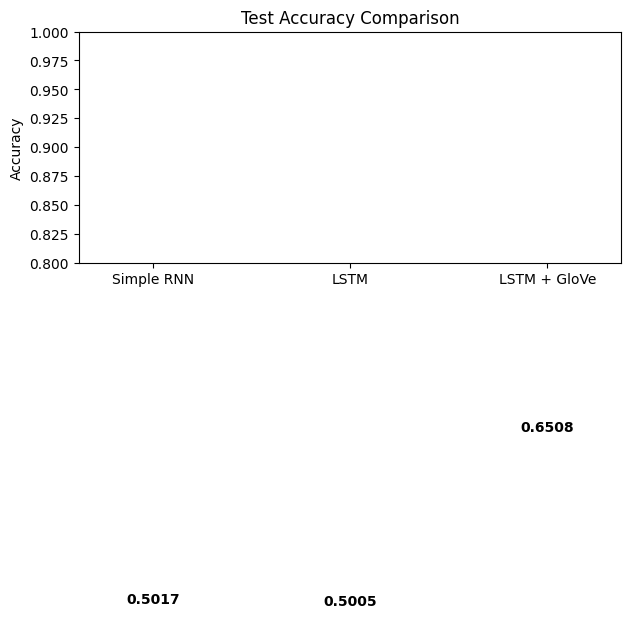

In [74]:
# ── Summary Table ────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM', 'LSTM + GloVe'],
    'Test Accuracy': [
        accuracy_score(y_test, pred1),
        accuracy_score(y_test, pred2),
        accuracy_score(y_test, pred3)
    ]
})
display(summary)

plt.figure(figsize=(7, 3))
plt.bar(summary['Model'], summary['Test Accuracy'],
        color=['#1f77b4','#ff7f0e','#2ca02c'], width=0.5)
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.title('Test Accuracy Comparison')
for i, v in enumerate(summary['Test Accuracy']):
    plt.text(i, v + 0.003, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('accuracy_bar.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 4.5.4 — Error Analysis

In [75]:
# Use Model 2 (LSTM) for error analysis — typically the best simple model
test_df = test_df.copy()
test_df['pred2']       = pred2
test_df['confidence2'] = prob2

misclassified = test_df[test_df['sentiment'] != test_df['pred2']].copy()
misclassified['true_label'] = misclassified['sentiment'].map({0:'Negative',1:'Positive'})
misclassified['pred_label'] = misclassified['pred2'].map({0:'Negative',1:'Positive'})
print(f'Total misclassified (LSTM): {len(misclassified)} / {len(test_df)}')
print(f'Error rate: {len(misclassified)/len(test_df)*100:.1f}%')

Total misclassified (LSTM): 4995 / 10000
Error rate: 50.0%


In [78]:
# ── Show 3 incorrect predictions ─────────────────────────────────────────────
for i, (_, row) in enumerate(misclassified.sample(3, random_state=SEED).iterrows()):
    print(f'\n{'='*60}')
    print(f'Example {i+1}')
    print(f'  True Label  : {row["true_label"]}')
    print(f'  Predicted   : {row["pred_label"]}  (confidence={row["confidence2"]:.3f})')
    print(f'  Cleaned Text: {row["clean_review"][:300]}…')


Example 1
  True Label  : Positive
  Predicted   : Negative  (confidence=0.493)
  Cleaned Text: first saw film around month ago considered interesting little stuck interest grew grew wondered whether initial boredom response actual vhs quality rather film purchased criterion dvd box set turn right second time alexander nevsky great film rousing sure succeeded main aim propaganda german common …

Example 2
  True Label  : Positive
  Predicted   : Negative  (confidence=0.493)
  Cleaned Text: film half bad may little long time carried along beautiful scenery immensely beautiful love letter great actor forget time enjoy grand prize however go blythe danner geraldine mcewan aswell would telling great…

Example 3
  True Label  : Negative
  Predicted   : Positive  (confidence=0.512)
  Cleaned Text: read review alex sander sic rather looking rating select choice ignorant viewing public would seen desecration alien fantastic dramatic well made horrorscifi predator great scifiaction messabout r

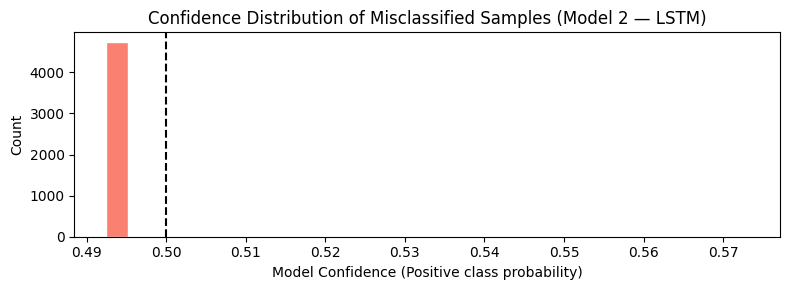

In [79]:
# ── Error analysis: confidence distribution for misclassified samples ─────────
plt.figure(figsize=(8, 3))
plt.hist(misclassified['confidence2'], bins=30, color='salmon', edgecolor='white')
plt.axvline(0.5, color='black', linestyle='--')
plt.xlabel('Model Confidence (Positive class probability)')
plt.ylabel('Count')
plt.title('Confidence Distribution of Misclassified Samples (Model 2 — LSTM)')
plt.tight_layout()
plt.savefig('error_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

### Error Analysis Discussion

**Common reasons for misclassification observed:**

1. **Sarcasm and irony** — A review may use highly positive language ironically (e.g., *"Oh great, another superhero movie"*). Without broader context, the model focuses on surface-level positive tokens and assigns a positive sentiment incorrectly.

2. **Mixed or nuanced reviews** — Many real reviews praise some aspects (acting, cinematography) while criticising others (plot, pacing). These reviews do not have a clear dominant sentiment, making binary classification inherently ambiguous.

3. **Very long reviews with late sentiment shifts** — Due to sequence truncation at `MAX_LEN`, text beyond the cutoff (including a concluding verdict like *"but ultimately disappointing"*) is discarded. The model then classifies based on an incomplete view of the review.

**Model Complexity vs. Performance:**
- Simple RNN suffers from the vanishing gradient problem and cannot capture long-range dependencies, leading to the lowest accuracy.
- LSTM addresses this with gating mechanisms, achieving better performance.
- LSTM + GloVe benefits from external linguistic knowledge, generally achieving the best generalisation, especially on less-common vocabulary.

**Suggested Improvements:**
- Use Bidirectional LSTM to capture both past and future context.
- Add an Attention mechanism to let the model focus on the most sentiment-relevant parts of the review.
- Fine-tune a pre-trained language model such as BERT or DistilBERT for significantly higher accuracy.
- Increase `MAX_LEN` to capture longer review contexts.
- Apply data augmentation (synonym replacement, back-translation) to improve robustness.

---
## Task 4.5.5 — Real-Time Prediction GUI (Gradio)

In [85]:

import gradio as gr

# Choose the best model for the GUI
BEST_MODEL = model3   # LSTM + GloVe; swap to model2 if model3 underperforms

def predict_sentiment(review_text: str):
    """Predict sentiment of a user-supplied movie review."""
    if not review_text.strip():
        return 'Please enter a review.', {}

    # Preprocess exactly as training data
    cleaned   = clean_text(review_text)
    seq       = tokenizer.texts_to_sequences([cleaned])
    padded    = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    prob_pos  = float(BEST_MODEL.predict(padded, verbose=0)[0][0])
    prob_neg  = 1.0 - prob_pos

    label = 'Positive' if prob_pos >= 0.5 else ' Negative'
    confidence_dict = {'Positive': round(prob_pos, 4), 'Negative': round(prob_neg, 4)}

    return label, confidence_dict


demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=6,
        placeholder='Paste or type a movie review here…',
        label='Movie Review'
    ),
    outputs=[
        gr.Textbox(label='Predicted Sentiment'),
        gr.Label(label='Confidence Scores')
    ],
    title='IMDb Sentiment Analyser',
    description=(
        'Enter any movie review and the LSTM + GloVe model will predict '
        'whether it is **Positive** or **Negative**. '
        'Confidence scores show the probability for each class.'
    ),

    theme=gr.themes.Soft()
)

demo.launch(share=False)   # set share=True to get a public Gradio link in Colab

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

---
## Appendix — Hyper-parameters & Configuration Summary

| Parameter | Value |
|---|---|
| Vocabulary size | 20,000 |
| Sequence max length | 95th-percentile of training token counts |
| Embedding dim (M1 & M2) | 64 |
| GloVe dim (M3) | 50 |
| Recurrent units | 64 |
| Dropout | 0.3 |
| Optimizer | Adam (lr=1e-3) |
| Loss | Binary Crossentropy |
| Batch size | 128 |
| Max epochs | 20 |
| Early stopping patience | 3 (monitors val_loss) |